# Public Transport Delay Prediction using Machine Learning

## Business Problem

Public transportation systems are critical for urban mobility. Delays caused by weather conditions, traffic congestion, holidays, public events, and operational issues reduce passenger satisfaction and increase operational costs.

The objective of this project is to develop a machine learning model capable of predicting whether a public transport trip will be delayed based on scheduling information, weather conditions, traffic levels, and city events.

Such predictions can help transport authorities:

- Improve operational planning
- Optimize route scheduling
- Inform passengers proactively
- Reduce congestion
- Improve service reliability

---

## Project Objectives

This project aims to:

- Understand the dataset through Exploratory Data Analysis (EDA)
- Identify important factors contributing to transport delays
- Engineer meaningful features
- Build multiple Machine Learning models
- Compare model performance
- Explain predictions using Explainable AI (SHAP)

---

## Dataset Overview

The dataset contains information related to

- Transport schedules
- Weather
- Traffic conditions
- Public events
- Holidays
- Peak hours
- Delay information

Target Variable

**Delayed**

- 0 → On Time
- 1 → Delayed

In [1]:
#import libraries 

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

In [2]:
#load dataset

df = pd.read_csv("data/public_transport_delays.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/public_transport_delays.csv'

In [ ]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2000
Number of Columns : 24


In [ ]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
actual_departure_delay_min,2000.0,8.68800,6.268118,-2.0,3.0,9.0,14.0,19.0
actual_arrival_delay_min,2000.0,13.31800,9.289727,-3.0,5.0,13.0,21.0,29.0
temperature_C,2000.0,15.12135,11.479424,-5.0,5.1,15.3,24.8,35.0
humidity_percent,2000.0,64.71400,20.334747,30.0,46.0,65.0,83.0,99.0
wind_speed_kmh,2000.0,29.30050,17.264015,0.0,15.0,29.0,45.0,59.0
precipitation_mm,2000.0,9.86070,5.781373,0.0,4.9,9.7,14.8,20.0
event_attendance_est,2000.0,6420.25000,15198.306129,0.0,0.0,0.0,2000.0,50000.0
traffic_congestion_index,2000.0,50.24400,29.225751,0.0,25.0,50.0,76.0,99.0
holiday,2000.0,0.08950,0.285535,0.0,0.0,0.0,0.0,1.0
peak_hour,2000.0,0.27200,0.445101,0.0,0.0,0.0,1.0,1.0


In [ ]:
df.describe(include="object").T

,count,unique,top,freq
trip_id,2000,2000,T00000,1
date,2000,22,2023-01-12,96
time,2000,96,05:00:00,21
transport_type,2000,4,Bus,525
route_id,2000,20,Route_3,114
origin_station,2000,50,Station_17,55
destination_station,2000,50,Station_26,56
scheduled_departure,2000,474,11:46:00,11
scheduled_arrival,2000,1068,12:43:00,7
weather_condition,2000,6,Clear,343


The dataset contains information about public transport trips, including schedule, delays, weather, traffic, and special events.

# Categorical Columns
trip_id : Unique ID for each trip 
>
transport_type : Type of transport (bus, train, etc.)
>
route_id : Route identifier
>
origin_station : Starting station
>
destination_station : Ending station
>
weather_condition : Weather description
>
event_type : Type of event (if any)
holiday : Whether the day is a public holiday
>
peak_hour : Whether the trip occurs during peak hours
>
weekday : Day of the week
>
season : Season
>
delayed : Whether the trip was delayed (0 = No, 1 = Yes)
>
# Numeric Columns
temperature_C : Temperature in Celsius
>
humidity_percent : Humidity (%)
>
wind_speed_kmh : Wind speed (km/h)
>
precipitation_mm : Precipitation (mm)
>
event_attendance_est : Estimated number of people attending the event
>
traffic_congestion_index : Traffic congestion level
>
actual_departure_delay_min : Departure delay in minutes
>
actual_arrival_delay_min : Arrival delay in minutes
>
# Datetime Columns
>
date : Date of the trip
>
time : Time of the trip
>
scheduled_departure : Scheduled departure time
>
scheduled_arrival : Scheduled arrival time

In [ ]:
#Data Quality Report

report = pd.DataFrame({

"Data Type":df.dtypes,

"Missing Values":df.isnull().sum(),

"Missing %":round(df.isnull().sum()/len(df)*100,2),

"Unique Values":df.nunique(),

"Duplicate":df.duplicated().sum()

})

report

,Data Type,Missing Values,Missing %,Unique Values,Duplicate
trip_id,object,0,0.00,2000,0
date,object,0,0.00,22,0
time,object,0,0.00,96,0
transport_type,object,0,0.00,4,0
route_id,object,0,0.00,20,0
origin_station,object,0,0.00,50,0
destination_station,object,0,0.00,50,0
scheduled_departure,object,0,0.00,474,0
scheduled_arrival,object,0,0.00,1068,0
actual_departure_delay_min,int64,0,0.00,22,0


C:\Users\srisa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\categorical.py:1281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)


<Axes: xlabel='delayed', ylabel='count'>

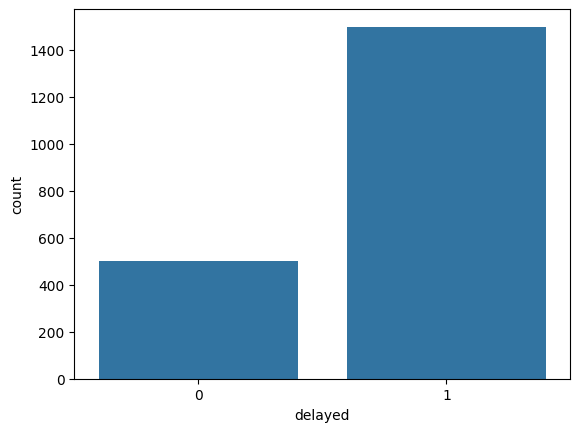

In [ ]:
sns.countplot(df,x='delayed')